In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import config

# Matched filtering needs the float64 dynamic range; enable it before any
# JAX array is created.
config.update("jax_enable_x64", True)

import optax

from gwpy.timeseries import TimeSeries
from gwpy.frequencyseries import FrequencySeries
from ripplegw.waveforms import IMRPhenomD

print(f"JAX backend: {jax.default_backend()}   devices: {jax.devices()}")

# ripple's IMRPhenomD is written in JAX and is differentiable out of the
# box, so -- unlike the torch + ml4gw version -- no autograd shims are
# needed here. The generator
#
#     IMRPhenomD.gen_IMRPhenomD_hphc(f, theta, f_ref)
#
# takes a flat parameter vector
#
#     theta = [Mc, eta, chi1, chi2, distance, tc, phic, inclination]
#
# and returns (h_plus, h_cross) on the frequency grid `f`.

JAX backend: cpu   devices: [CpuDevice(id=0)]


## Load generated data

True, time-delayed O3a detector noise plus an injected synthetic signal.
Truth parameters are kept under `/truth` for cross-checks.

In [2]:
arrays = {}
with h5py.File("example_data/data_BBH_highSNR.h5", "r") as f:
    f.visititems(
        lambda name, obj: arrays.update({name: obj[...]})
        if isinstance(obj, h5py.Dataset) else None
    )

for name, arr in arrays.items():
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}")

ifo = "H1"
color = {"H1": "#ee0000", "L1": "#4ba6ff"}[ifo]
fs = 4096
N = arrays[f"{ifo}/strain"].shape[0]


H1/psd: shape=(16385,), dtype=float64
H1/strain: shape=(32768,), dtype=float32
L1/psd: shape=(16385,), dtype=float64
L1/strain: shape=(32768,), dtype=float32
antenna/H1/fcross: shape=(), dtype=float64
antenna/H1/fplus: shape=(), dtype=float64
antenna/L1/fcross: shape=(), dtype=float64
antenna/L1/fplus: shape=(), dtype=float64
truth/chi1: shape=(), dtype=float32
truth/chi2: shape=(), dtype=float32
truth/chirp_mass: shape=(), dtype=float32
truth/dec: shape=(), dtype=float32
truth/distance: shape=(), dtype=float32
truth/inclination: shape=(), dtype=float32
truth/mass_1: shape=(), dtype=float32
truth/mass_2: shape=(), dtype=float32
truth/mass_ratio: shape=(), dtype=float32
truth/phi: shape=(), dtype=float32
truth/phic: shape=(), dtype=float32
truth/psi: shape=(), dtype=float32
truth/s1z: shape=(), dtype=float32
truth/s2z: shape=(), dtype=float32
truth/snr: shape=(), dtype=float32
truth/snr_H1: shape=(), dtype=float32
truth/snr_L1: shape=(), dtype=float32
truth/tc: shape=(), dtype=float64


## Inputs in time and frequency space

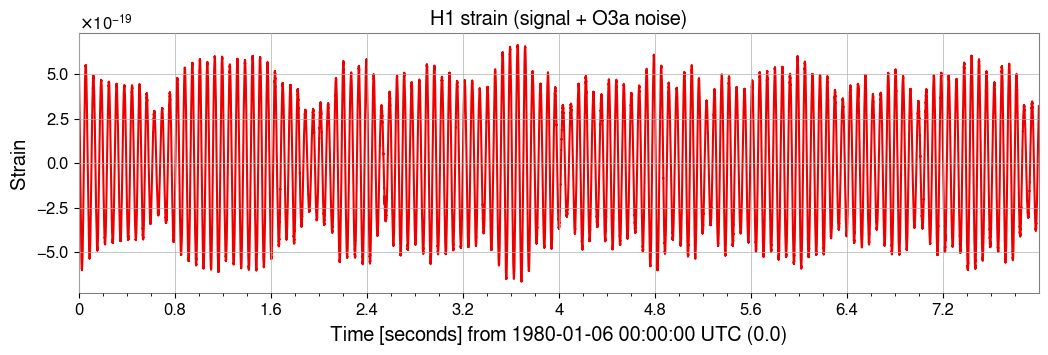

In [3]:
strain_ts = TimeSeries(arrays[f"{ifo}/strain"], t0=0, sample_rate=fs)
psd_fs = FrequencySeries(arrays[f"{ifo}/psd"], f0=0, df=fs / N)

strain_ts.plot(
    title=f"{ifo} strain (signal + O3a noise)", ylabel="Strain", color=color,
).show()

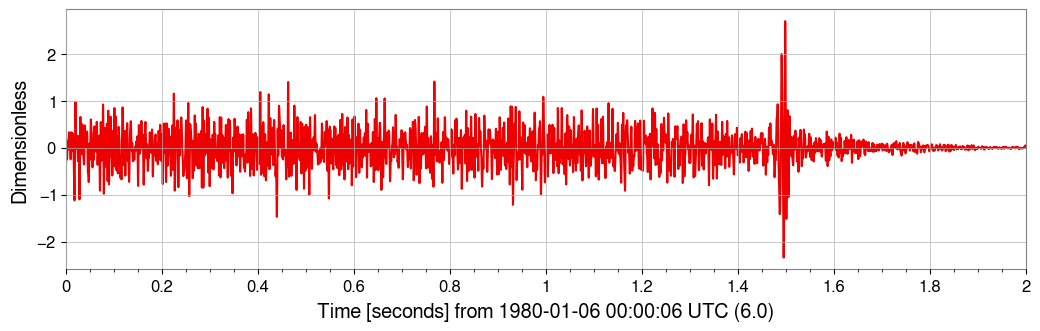

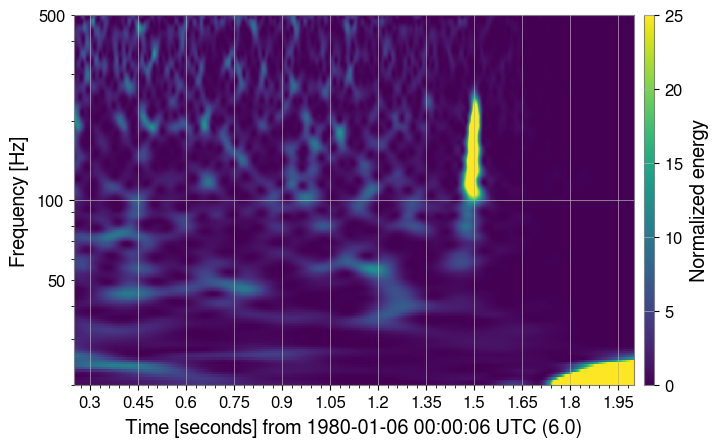

In [4]:
white = strain_ts.whiten(asd=psd_fs ** 0.5).bandpass(30, 400)
plot = white.plot(color=color)
plot.gca().set_xlim(6.0, 8.0)
plot.show()

qtrans = white.q_transform(frange=(20, 500), outseg=(6.25, 8), whiten=False)
plot = qtrans.plot(figsize=(8, 5), vmin=0, vmax=25)
ax = plot.gca()
ax.set_yscale("log")
ax.set_ylabel("Frequency [Hz]")
plot.colorbar(label="Normalized energy")
plot.show()

## Matched filtering with JAX + ripple

Build the per-detector matched-filter inputs on the segment rFFT grid as
JAX arrays and generate the template with `ripplegw`'s `IMRPhenomD` — an
independent JAX implementation of the same `IMRPhenomD` waveform
(1508.07253) that `GWDatasetGeneration` (via `ml4gw`) uses to *make* the
BBH injections. The mc-independent matched-filter weights are precomputed
once per detector, so the fit only ever regenerates the template. As a
baseline, check that `sqrt<h|h>` at the truth parameters reproduces the
stored per-detector and network SNR.

In [5]:
N = arrays["H1/strain"].shape[0]
df = fs / N
f_ref = 20.0
freqs = jnp.fft.rfftfreq(N, d=1.0 / fs)
band = (freqs >= 20) & (freqs <= fs / 2)
band_idx = jnp.nonzero(band)[0]
f_band = freqs[band]

# Tukey(alpha=0.01) on the strain matches the PSD's segment-edge treatment
# without eating the merger (only the first/last 1% of samples are tapered).
n_tukey = int(round(0.01 * N / 2))
ramp = 0.5 * (1 - np.cos(np.pi * (np.arange(n_tukey) + 0.5) / n_tukey))
window_td = jnp.asarray(np.concatenate([ramp, np.ones(N - 2 * n_tukey), ramp[::-1]]))

# Per-detector inputs, precomputed once and reduced to the band so the hot
# loop only ever touches band-length arrays. The mc-independent pieces of
# the matched filter are baked in here:
#   d_band_w     = conj(d~) / S_n   (data-side matched-filter weight)
#   inv_psd_band = 1 / S_n
detectors = {}
for det in ("H1", "L1"):
    strain_det = jnp.asarray(arrays[f"{det}/strain"])
    psd_det = jnp.asarray(arrays[f"{det}/psd"])
    d_full = jnp.fft.rfft(strain_det * window_td) / fs
    psd_safe = jnp.where(band, psd_det, jnp.inf)
    detectors[det] = {
        "fplus": float(arrays[f"antenna/{det}/fplus"]),
        "fcross": float(arrays[f"antenna/{det}/fcross"]),
        "d_band_w": (jnp.conj(d_full) / psd_safe)[band],
        "inv_psd_band": (1.0 / psd_det)[band],
    }

# Non-mass parameters held fixed at truth. ripple wants the symmetric mass
# ratio eta = q / (1 + q)^2 and a coalescence time tc that enters only as a
# linear-in-f phase, which the matched filter's max_t absorbs, so tc = 0.
mass_ratio = float(arrays["truth/mass_ratio"])
fixed = dict(
    eta=mass_ratio / (1.0 + mass_ratio) ** 2,
    chi1=float(arrays["truth/chi1"]),
    chi2=float(arrays["truth/chi2"]),
    distance=float(arrays["truth/distance"]),
    phic=float(arrays["truth/phic"]),
    inclination=float(arrays["truth/inclination"]),
)

mc_truth = float(arrays["truth/chirp_mass"])
truth_snr_net = float(arrays["truth/snr"])


def waveform(mc):
    """ripple (h+, hx) on the in-band grid. One call feeds both detectors."""
    theta = jnp.array([
        mc, fixed["eta"], fixed["chi1"], fixed["chi2"],
        fixed["distance"], 0.0, fixed["phic"], fixed["inclination"],
    ])
    return IMRPhenomD.gen_IMRPhenomD_hphc(f_band, theta, f_ref)


def matched_filter(hp, hc, det):
    """(<h|h>, z(t)) for one detector from the precomputed band quantities."""
    h_band = det["fplus"] * hp + det["fcross"] * hc
    hh = 4.0 * df * jnp.sum(jnp.abs(h_band) ** 2 * det["inv_psd_band"])
    spec = jnp.zeros(N, dtype=jnp.complex128).at[band_idx].set(
        det["d_band_w"] * h_band
    )
    z = 4.0 * fs * jnp.fft.ifft(spec)
    return hh, z

In [6]:
hp0, hc0 = waveform(mc_truth)
rho_sq_net = 0.0
for det_name, det in detectors.items():
    hh, _ = matched_filter(hp0, hc0, det)
    rho_sq_net += float(hh)
    print(f"{det_name}    : sqrt<h|h> = {float(jnp.sqrt(hh)):7.3f}   "
          f"truth SNR = {float(arrays[f'truth/snr_{det_name}']):.3f}")
print(f"network : sqrt<h|h> = {np.sqrt(rho_sq_net):7.3f}   "
      f"truth SNR = {truth_snr_net:.3f}")

H1    : sqrt<h|h> =  30.905   truth SNR = 30.905
L1    : sqrt<h|h> =  55.727   truth SNR = 55.727
network : sqrt<h|h> =  63.723   truth SNR = 63.723


## Matched filter — time-maximised SNR

`z(t) = 4 ∫ conj(d̃) h̃ e^{2πift} / S_n(f) df` is the cross-correlation of
data and template over all time shifts; `ρ(t) = |z(t)| / sqrt(<h|h>)` is
the phase-maximised SNR. Its peak in H1 gives the recovered coalescence
time, with the truth template as a baseline.

In [7]:
det = detectors["H1"]
hp0, hc0 = waveform(mc_truth)
hh, z_t = matched_filter(hp0, hc0, det)
rho_t = jnp.abs(z_t) / jnp.sqrt(hh)
peak_idx = int(jnp.argmax(rho_t))

# The ifft index encodes the *relative* shift τ_peak between data and
# template, with periodic wrap-around: indices > N/2 map to negative
# shifts. Recovered coalescence time: tc_data = tc_template − τ_peak.
tc_template = float(arrays["truth/tc"])
tau_peak = (peak_idx if peak_idx < N // 2 else peak_idx - N) / fs
tc_recovered = tc_template - tau_peak

print(f"<h|h>               : {float(hh):.3f}")
print(f"Matched-filter peak : {float(rho_t[peak_idx]):.3f}")
print(f"  shift τ_peak      : {tau_peak * 1e3:+.3f} ms")
print(f"  recovered tc      : {tc_recovered:.4f} s   (truth tc: {tc_template:.4f} s)")
print(f"True H1 SNR         : {float(arrays['truth/snr_H1']):.3f}")

<h|h>               : 955.117
Matched-filter peak : 32.024
  shift τ_peak      : +486.328 ms
  recovered tc      : 7.0137 s   (truth tc: 7.5000 s)
True H1 SNR         : 30.905


## Fit the chirp mass with JAX + ripple

Gradient-descend the network statistic `-(ρ²_H1 + ρ²_L1)`, each `ρ²`
time-maximised with a single inverse FFT, with `jax.grad` straight through
the `ripple` waveform. Two things keep it fast:

- `h+, hx` are generated **once per step** and shared between detectors, so
  each step costs a single waveform call;
- the whole 500-step Adam loop is fused into one `jax.lax.scan` under a
  single `jax.jit`, so there is no Python-loop or host-sync overhead.

Time-maximising via the ifft removes the need to fit `tc`: as `Mc` moves the
merger drifts inside the segment and `max_t` tracks it automatically.

In [8]:
def network_loss(mc):
    """-(ρ²_H1 + ρ²_L1), each ρ² time-maximised with one inverse FFT.

    `h+, hx` come from a single ripple call and are reused for every
    detector.
    """
    hp, hc = waveform(mc)
    rho_sq = 0.0
    for det in detectors.values():
        hh, z = matched_filter(hp, hc, det)
        rho_sq = rho_sq + jnp.max(jnp.abs(z) ** 2) / hh
    return -rho_sq


# Jitted handle reused by the loss landscape (and composed inside the fit).
loss_jit = jax.jit(network_loss)

In [9]:
n_steps = 500


@jax.jit
def run_fit(mc_init):
    """Full Adam + cosine-decay fit fused into one jitted lax.scan."""
    schedule = optax.cosine_decay_schedule(0.1, n_steps, alpha=1e-3 / 0.1)
    optimizer = optax.adam(schedule)
    grad_fn = jax.value_and_grad(network_loss)

    def step(carry, _):
        mc, opt_state = carry
        loss, grad = grad_fn(mc)                       # record before stepping
        updates, opt_state = optimizer.update(grad, opt_state, mc)
        mc = optax.apply_updates(mc, updates)
        return (mc, opt_state), (mc, jnp.sqrt(-loss))

    init = (mc_init, optimizer.init(mc_init))
    _, (mc_hist, rho_hist) = jax.lax.scan(step, init, length=n_steps)
    return mc_hist, rho_hist


hist_mc, hist_rho = run_fit(jnp.asarray(mc_truth + 10.0))
hist_mc = np.asarray(hist_mc)
hist_rho = np.asarray(hist_rho)

print(f"Initial Mc : {hist_mc[0]:.4f} Msun   →  ρ_net = {hist_rho[0]:.3f}")
print(f"Final   Mc : {hist_mc[-1]:.4f} Msun   →  ρ_net = {hist_rho[-1]:.3f}")
print(f"Truth   Mc : {mc_truth:.4f} Msun           (truth ρ_net = {truth_snr_net:.3f})")

Initial Mc : 42.3014 Msun   →  ρ_net = 56.128
Final   Mc : 32.4077 Msun   →  ρ_net = 63.596
Truth   Mc : 32.4014 Msun           (truth ρ_net = 63.723)


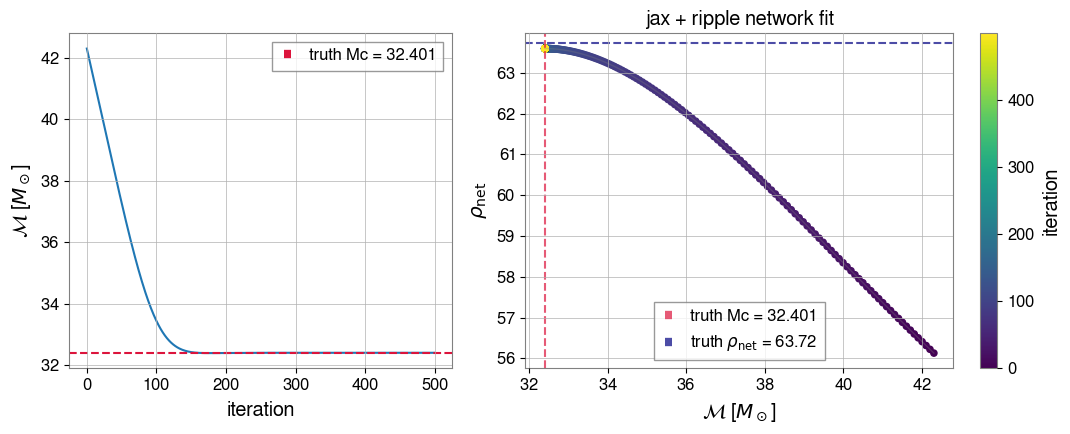

In [10]:
iters = np.arange(len(hist_mc))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.5),
                               gridspec_kw={"width_ratios": [1, 1.4]})
ax0.plot(iters, hist_mc, color="C0")
ax0.axhline(mc_truth, ls="--", color="crimson", label=f"truth Mc = {mc_truth:.3f}")
ax0.set_xlabel("iteration"); ax0.set_ylabel(r"$\mathcal{M}$ [$M_\odot$]"); ax0.legend()

sc = ax1.scatter(hist_mc, hist_rho, c=iters, cmap="viridis", s=20)
ax1.plot(hist_mc, hist_rho, color="gray", alpha=0.3, lw=1)
ax1.axvline(mc_truth, ls="--", color="crimson", alpha=0.7, label=f"truth Mc = {mc_truth:.3f}")
ax1.axhline(truth_snr_net, ls="--", color="navy", alpha=0.7,
            label=fr"truth $\rho_\mathrm{{net}}$ = {truth_snr_net:.2f}")
ax1.set_xlabel(r"$\mathcal{M}$ [$M_\odot$]"); ax1.set_ylabel(r"$\rho_\mathrm{net}$")
ax1.legend(); ax1.set_title("jax + ripple network fit")
fig.colorbar(sc, ax=ax1, label="iteration")
fig.tight_layout(); plt.show()

## Loss landscape of the chirp-mass fit

Scan the network statistic `ρ_net = sqrt(ρ²_H1 + ρ²_L1)` over a grid of
chirp masses (template regenerated at each `Mc`, time-maximised exactly as
in the fit) to visualise the objective the optimiser descends. The whole
grid is evaluated in a single vectorised `jax.vmap` call. The fit
trajectory is overlaid, its colour encoding iteration.

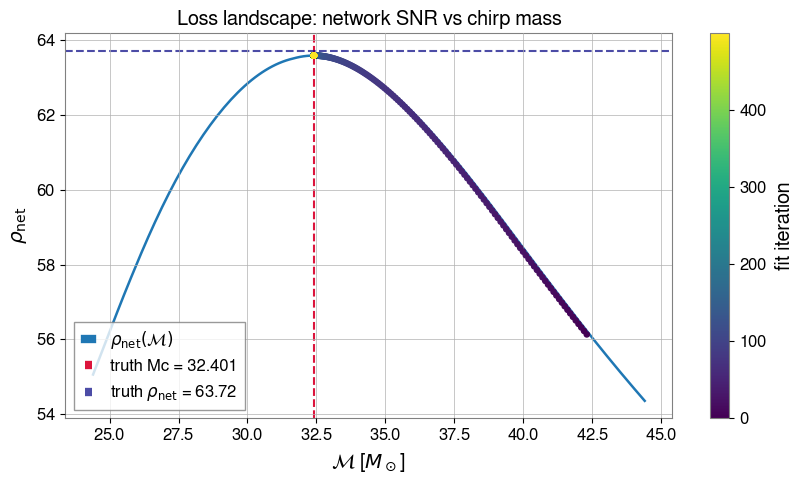

In [11]:
# Evaluate the (un-negated) network ρ_net on a grid of chirp masses in one
# vectorised pass: jax.vmap maps the jitted loss over the whole grid at
# once, replacing a 161-iteration Python loop.
mc_grid = jnp.linspace(mc_truth - 8.0, mc_truth + 12.0, 161)
rho_grid = np.asarray(jnp.sqrt(-jax.vmap(loss_jit)(mc_grid)))
mc_grid = np.asarray(mc_grid)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(mc_grid, rho_grid, color="C0", lw=1.8,
        label=r"$\rho_\mathrm{net}(\mathcal{M})$")
ax.axvline(mc_truth, ls="--", color="crimson", label=f"truth Mc = {mc_truth:.3f}")
ax.axhline(truth_snr_net, ls="--", color="navy", alpha=0.7,
           label=fr"truth $\rho_\mathrm{{net}}$ = {truth_snr_net:.2f}")
sc = ax.scatter(hist_mc, hist_rho, c=np.arange(len(hist_mc)), cmap="viridis",
                s=14, zorder=3)
ax.set_xlabel(r"$\mathcal{M}$ [$M_\odot$]"); ax.set_ylabel(r"$\rho_\mathrm{net}$")
ax.set_title("Loss landscape: network SNR vs chirp mass")
ax.legend(loc="lower left")
fig.colorbar(sc, ax=ax, label="fit iteration")
fig.tight_layout(); plt.show()